In [1]:
# importing the file

In [2]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.io import fits
import matplotlib.pyplot as plt

In [3]:
image = '../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits'
file = fits.open(image)

In [4]:
# image structure

In [5]:
file.info()

Filename: ../images/hlsp_ceers_jwst_nircam_nircam5_f444w_dr0.6_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     375   ()      
  1  SCI_BKSUB     1 ImageHDU        75   (11500, 6500)   float64   
  2  SCI           1 ImageHDU        75   (11500, 6500)   float32   
  3  ERR           1 ImageHDU        10   (11500, 6500)   float32   
  4  CON           1 ImageHDU        10   (11500, 6500, 1)   int32   
  5  WHT           1 ImageHDU         9   (11500, 6500)   float32   
  6  VAR_POISSON    1 ImageHDU         9   (11500, 6500)   float32   
  7  VAR_RNOISE    1 ImageHDU         9   (11500, 6500)   float32   
  8  VAR_FLAT      1 ImageHDU         9   (11500, 6500)   float32   
  9  BKGD          1 ImageHDU        39   (11500, 6500)   float64   
 10  BKGMASK       1 ImageHDU        41   (11500, 6500)   uint8 (rescales to int8)   
 11  HDRTAB        1 BinTableHDU    820   6R x 405C   [23A, 5A, 3A, 51A, 7A, 13A, 3A, 5A, 7A, 10A, 4A, L, 

In [6]:
sci = file["SCI"].data
err = file["ERR"].data
sci_bkgsub = file["SCI_BKSUB"].data

In [7]:
# subtracting the background by median method to exclue sky pixels from the glow of background. 

In [8]:
# note that we could use the "SCI_BKSUB" header of the original .fits file, but this section has written for educational purposes. 

In [9]:
# dropping the "NaN" values in array to avoid underestimations in thresholds. 

In [10]:
wht = file["WHT"].data
nodata = (wht <= 0) | (sci == 0) | ~np.isfinite(sci)
print(nodata.mean())

0.5013612173913043


In [11]:
sci

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(6500, 11500), dtype='>f4')

In [12]:
# finding the sky threshold and noise spread by investigating each 200px * 200px tile from the original image. 

In [13]:
h, w = sci.shape
tile = 200
n_rows, n_cols = h // tile, w // tile
medians = np.full((n_rows, n_cols), np.nan)
spreads = np.full((n_rows, n_cols), np.nan)

for i in range(n_rows):
    for j in range(n_cols):
        box      = sci[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        box_mask = nodata[i*tile:(i+1)*tile, j*tile:(j+1)*tile]
        real = box[~box_mask]
        if real.size < 0.5 * box.size:
            continue                            # leave this box as NaN
        mean, med, stddev = sigma_clipped_stats(real)
        medians[i, j] = med                     # sky level of this box
        spreads[i, j] = stddev 

In [14]:
# subtracting the sky treshold and noises from the "SCI" header to reveal the actual elements

In [15]:
sky   = np.nanmedian(medians)      # one global sky level
noise = np.nanmedian(spreads)      # one global noise level
rms   = np.sqrt(np.nanmedian(spreads**2))
n = 5                              # our chosen nsigma

threshold = sky + n * noise        # "center plus n spreads" — the line we draw
suspects = (sci > threshold) & ~nodata   # True where a pixel pokes above the line
print(suspects.mean())             # fraction of pixels flagged

0.012324334448160536


In [16]:
# plotting the mosaic with a tiny reduction in resolution (running this cell might take a while due to the line "plt.figure(figsize=(96, 48))")
# adjust the size if you need!

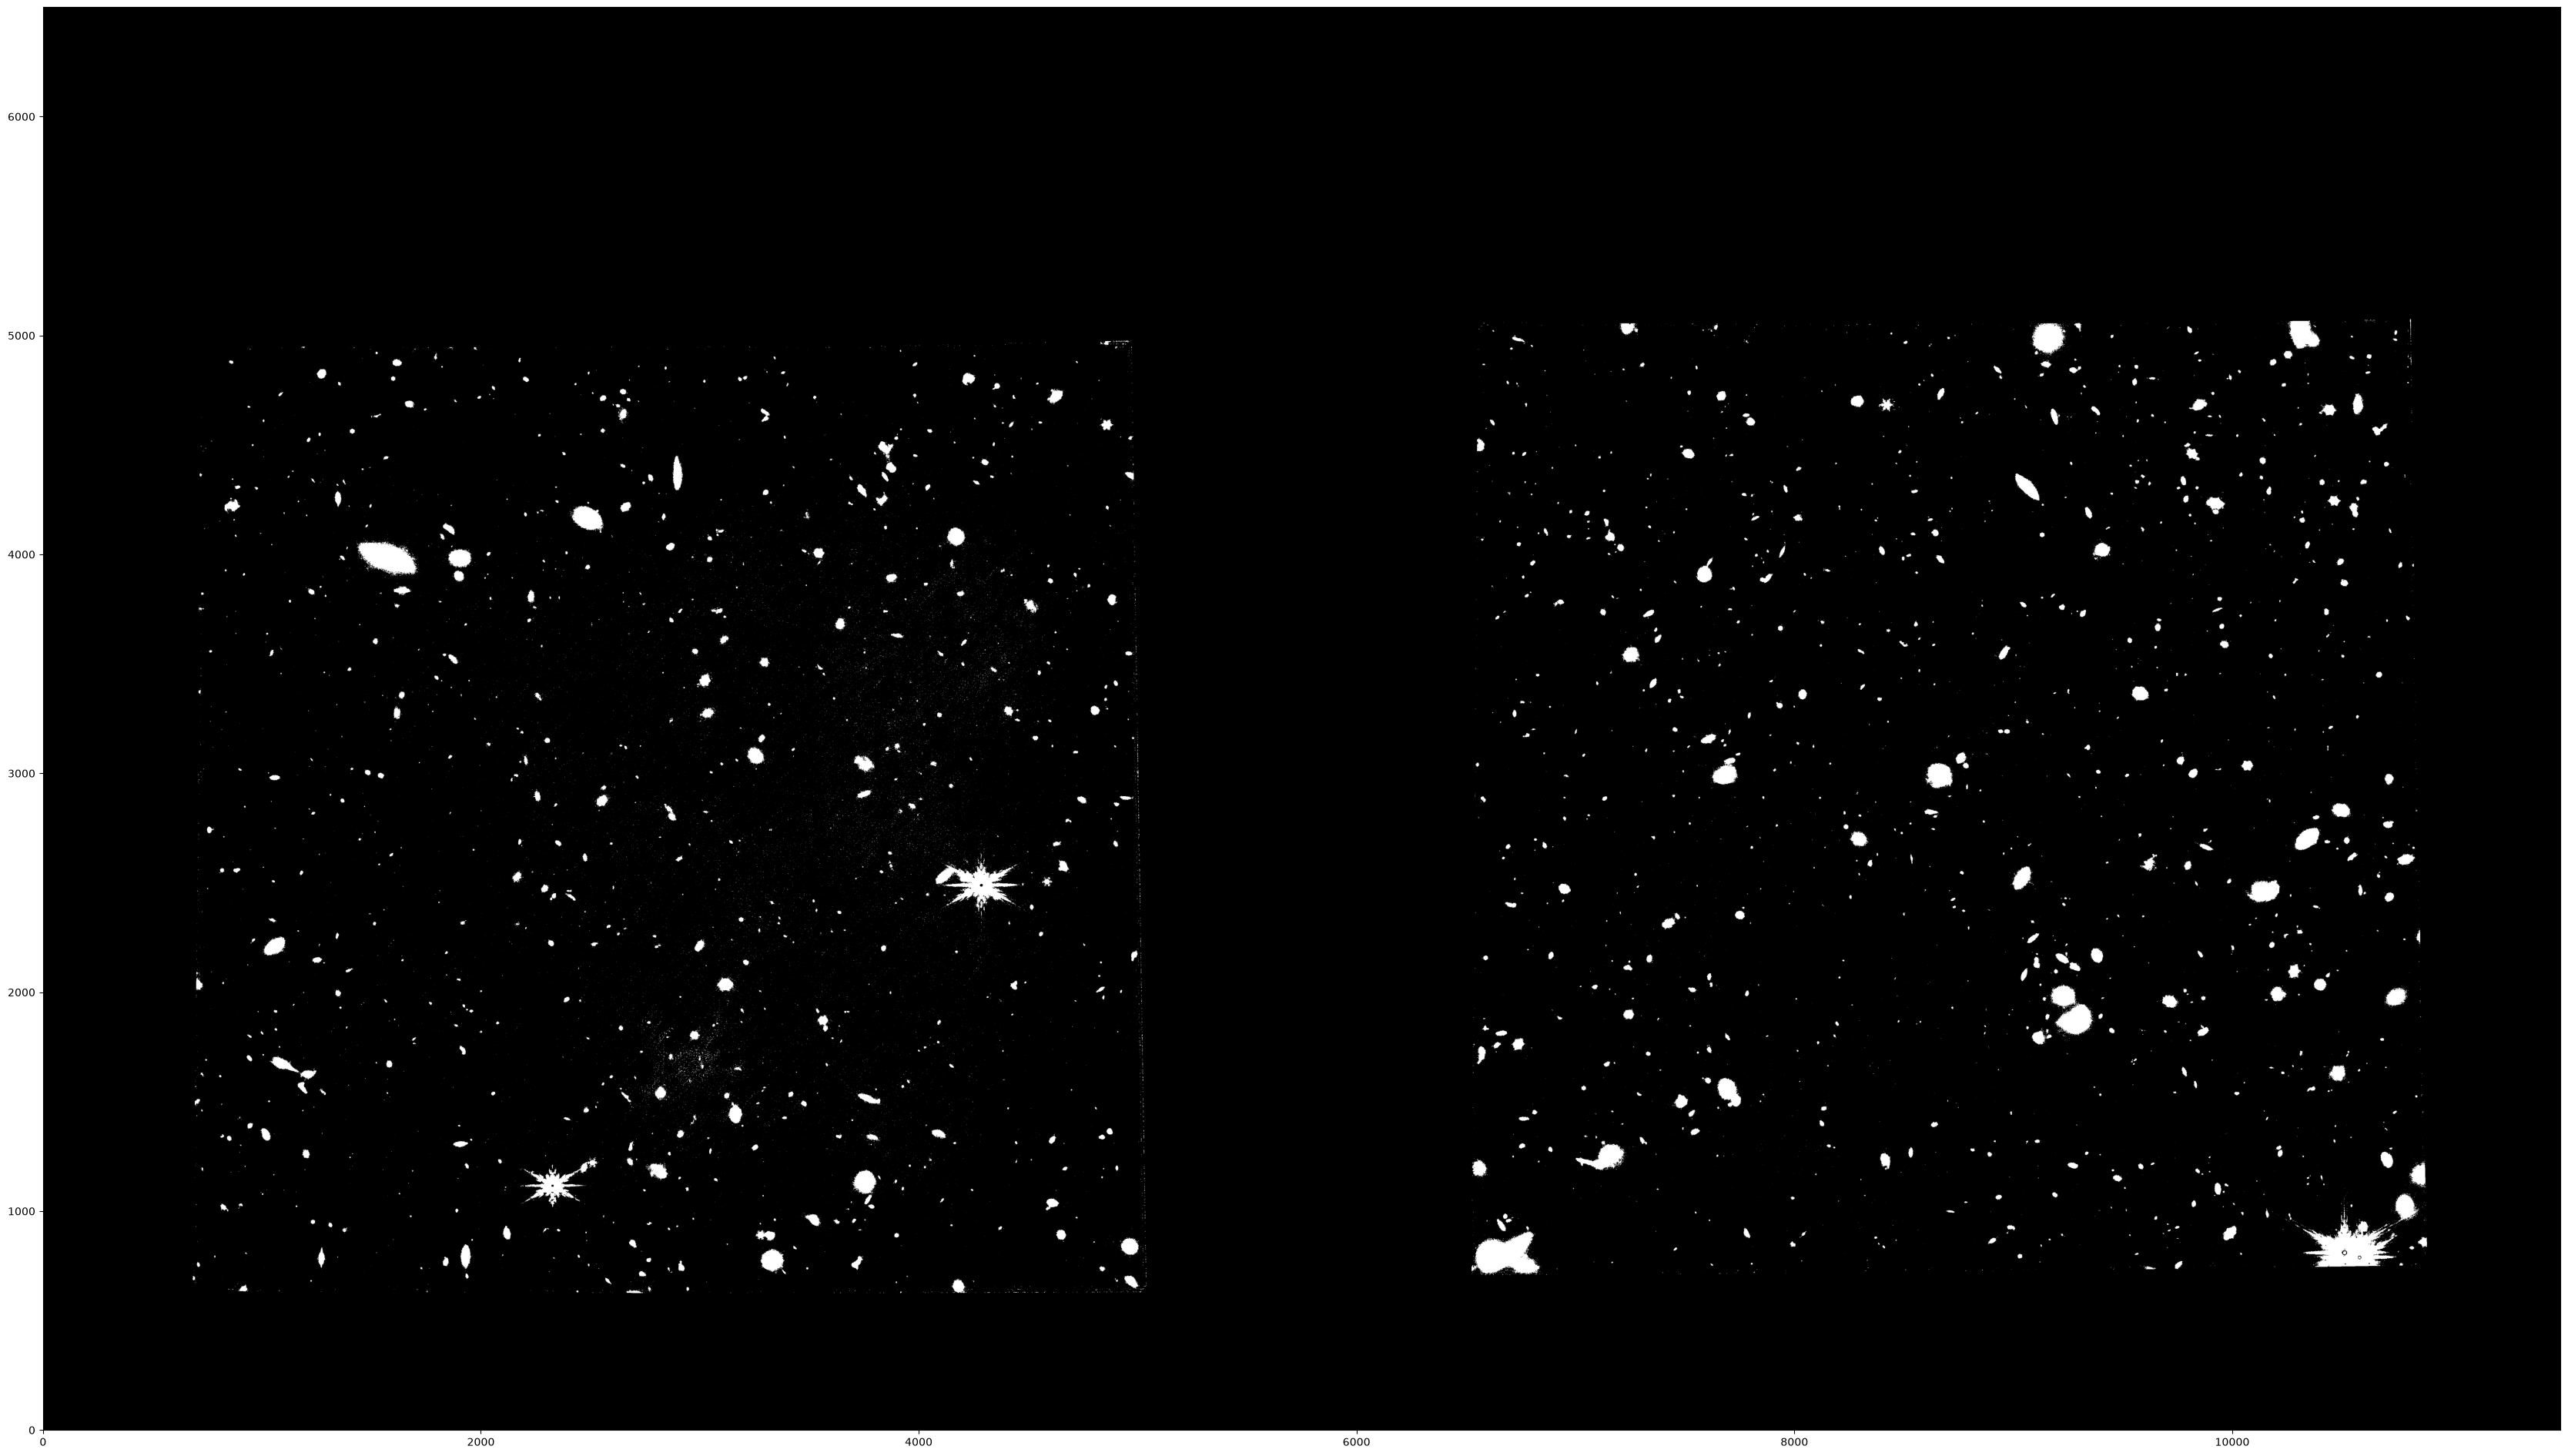

In [17]:
plt.figure(figsize=(48, 24))
plt.imshow(suspects, origin="lower", cmap="grey")
plt.show()

In [18]:
# source detection & labeling on a 2000px * 2000px testing tile

In [19]:
y0, y1, x0, x1 = 3000, 5000, 1000, 3000          # 2000px * 2000px sample to test the pipeline. 
cut      = sci[y0:y1, x0:x1].astype(np.float64)
cut_mask = nodata[y0:y1, x0:x1]
print(cut_mask.mean())                           # want this small — if near 1, pick a different region

0.02594725


In [20]:
# detecting sources

In [21]:
from photutils.segmentation import detect_sources

cut_sub = cut - sky
segm = detect_sources(cut_sub, threshold=n * noise, npixels=5, mask=cut_mask)
print(segm.nlabels)    # print how many objects detected above the defined threshold and noise spread. 

349


In [22]:
# plotting the detected sources (objects) beside the actual sky image

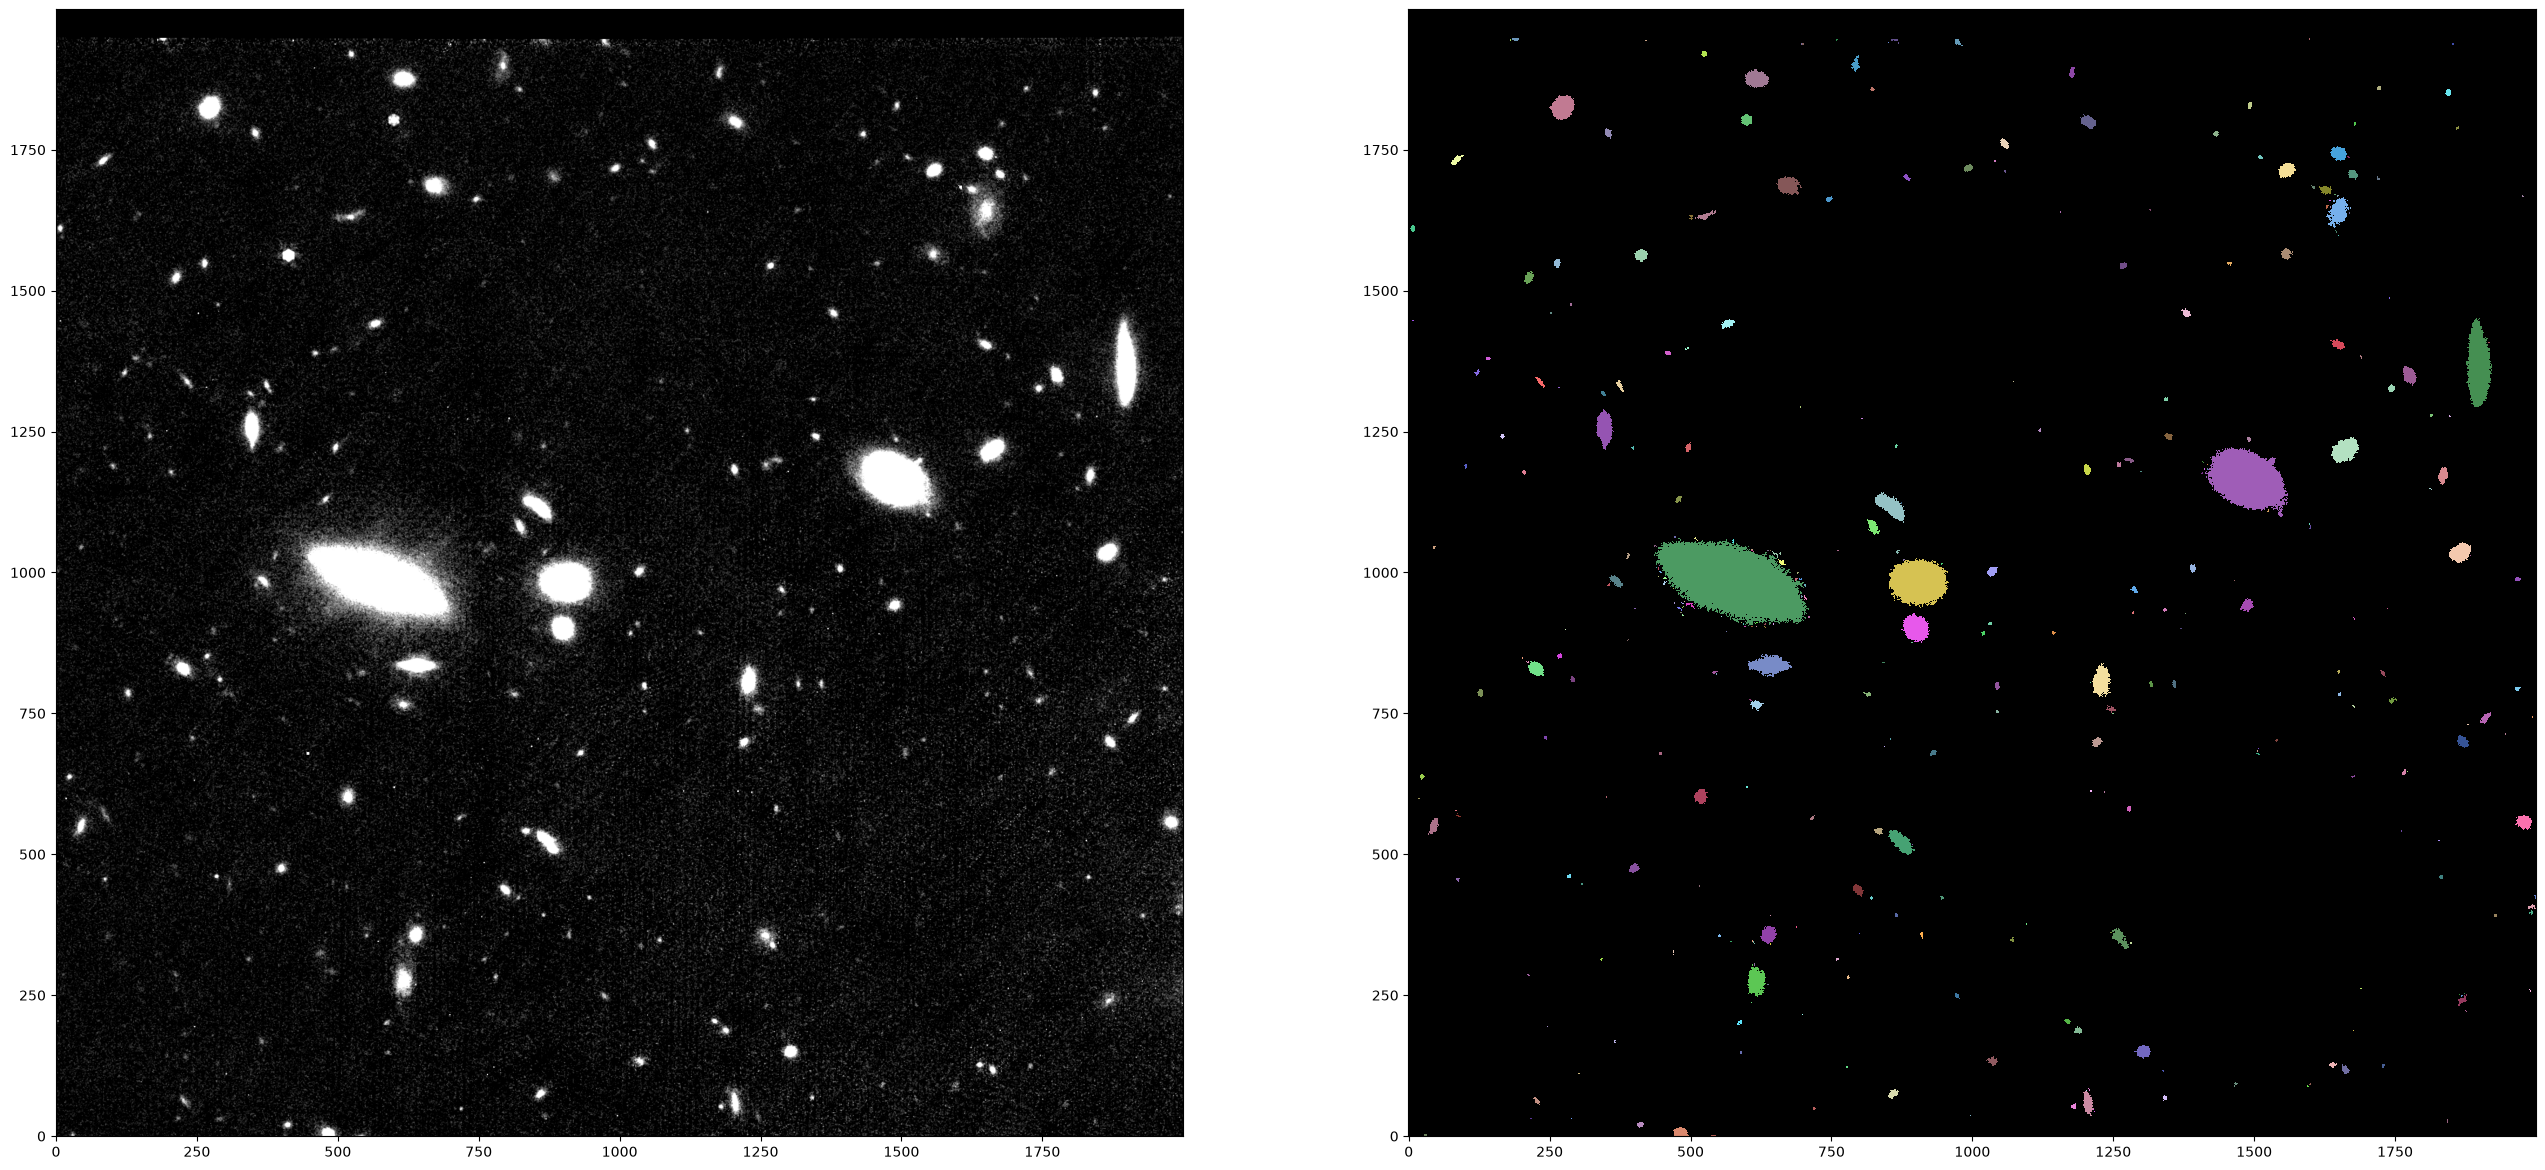

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm.data, origin="lower", cmap=segm.cmap, interpolation="nearest")
plt.show()

In [24]:
# enhancing the noise reduction by narrowing down the "noise" and "sky" tiles to avoid noises counted as a source

In [25]:
from scipy.ndimage import zoom

spreads_cut = spreads[15:25, 5:15]
spreads_cut = np.where(np.isnan(spreads_cut), rms, spreads_cut)
rms_cut = zoom(spreads_cut, 200, order=1, grid_mode=True, mode="nearest")

medians_cut = medians[15:25, 5:15]
medians_cut = np.where(np.isnan(medians_cut), sky, medians_cut)
sky_cut = zoom(medians_cut, 200, order=1, grid_mode=True, mode="nearest")
cut_sub = cut - sky_cut          # local sky map replaces the single global value
print(rms_cut.shape)

(2000, 2000)


In [26]:
# as you can see the number of detected sources decreased signifacntly! 

In [27]:
segm_local = detect_sources(cut_sub, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_local.n_labels)

228


In [28]:
# plotting the remaining sources

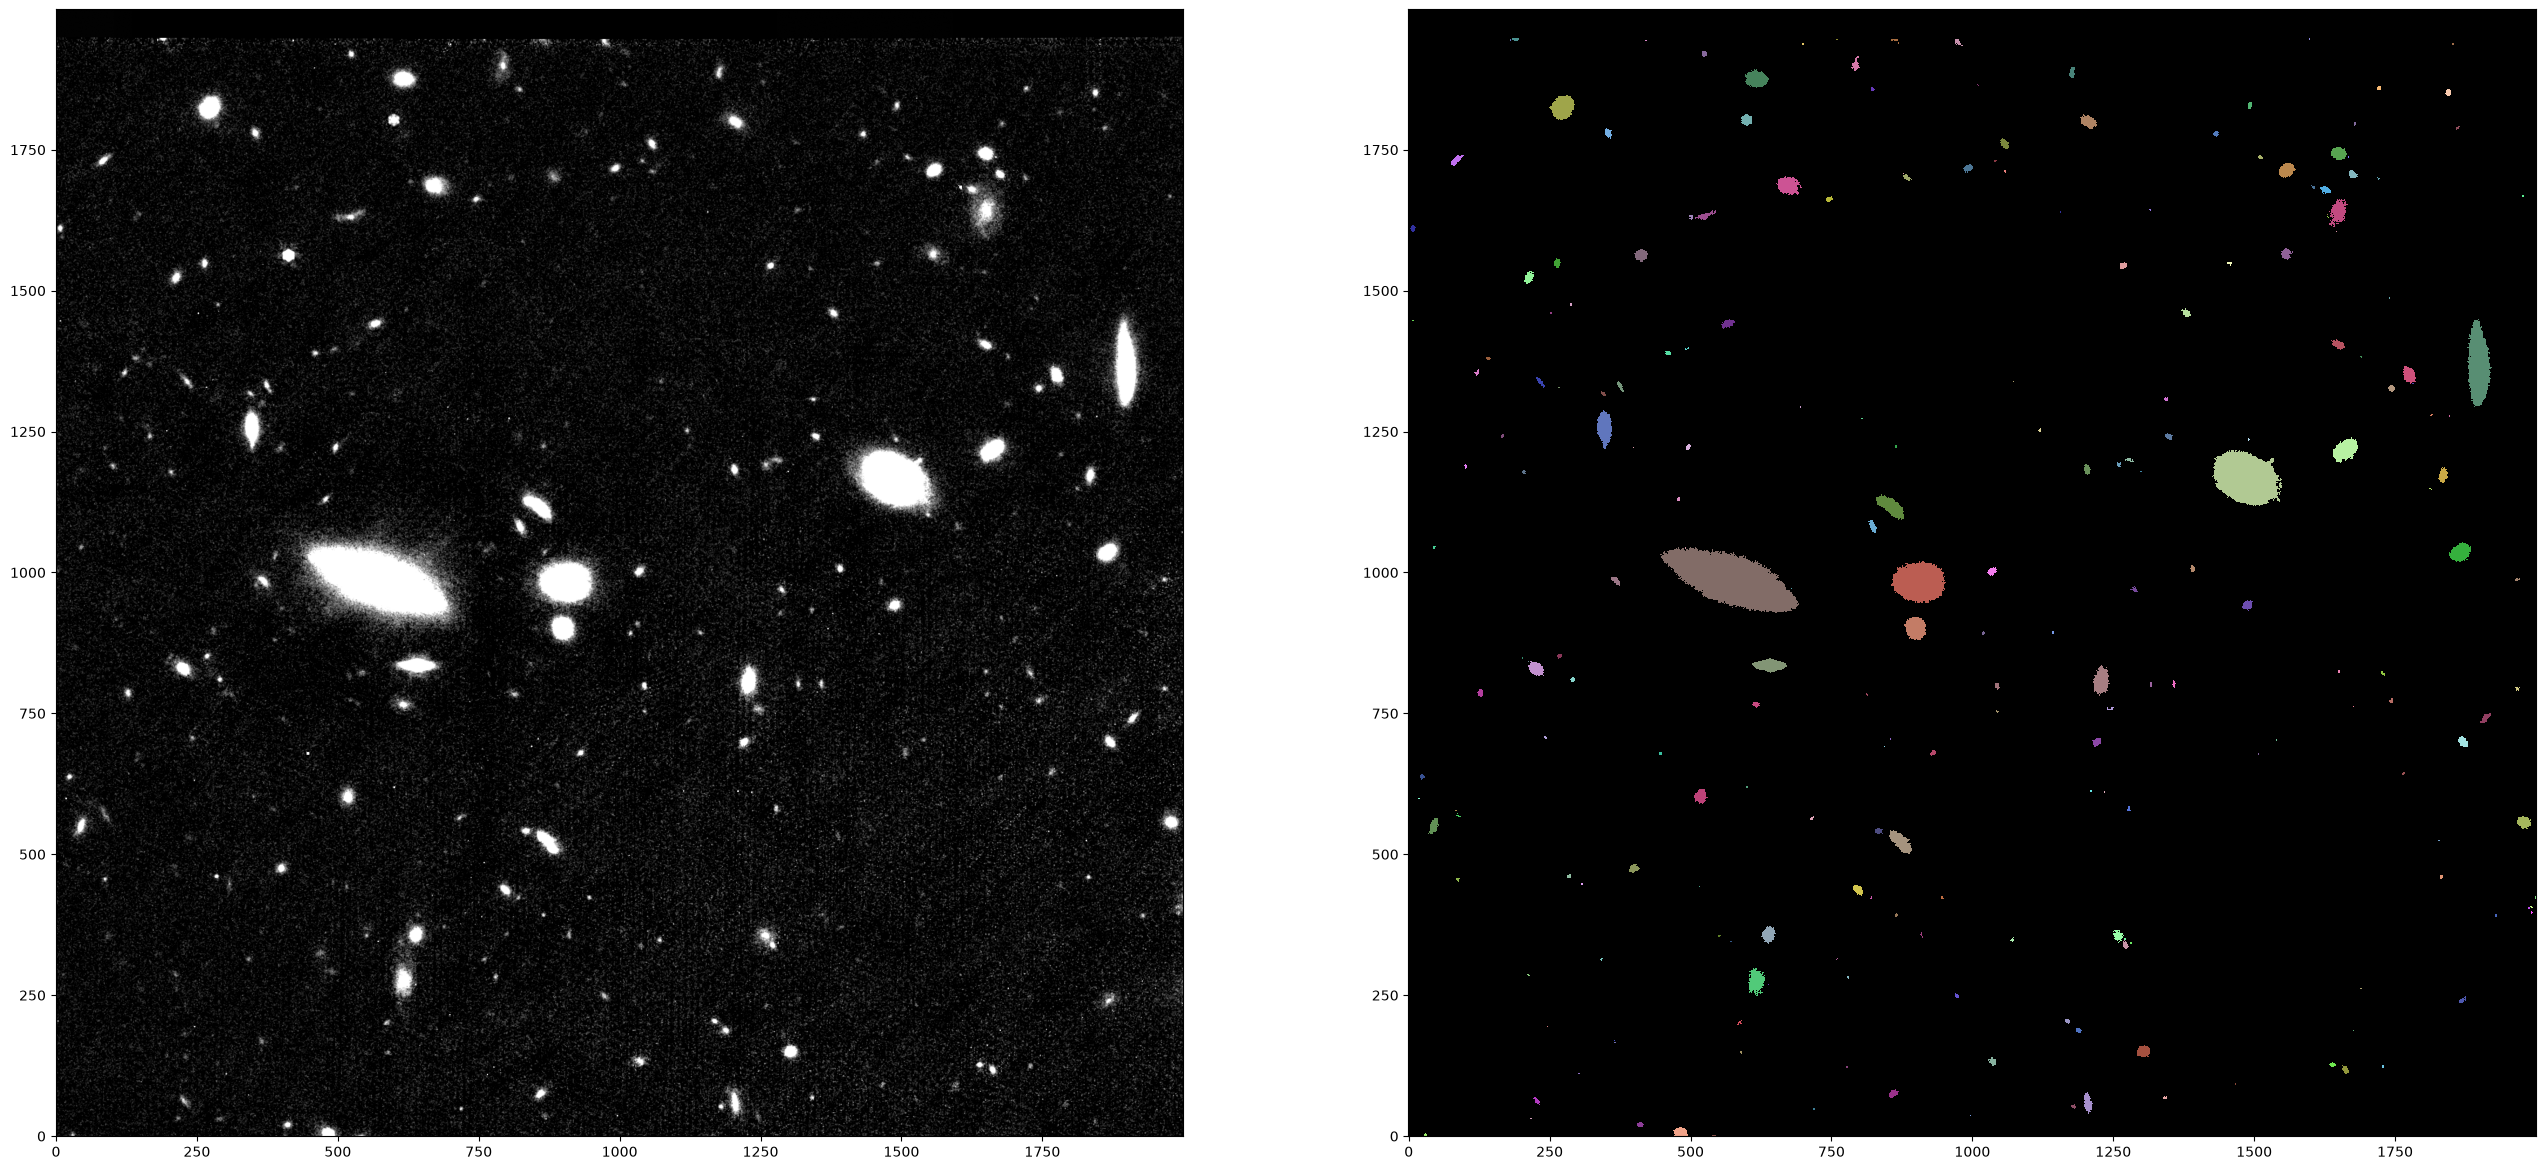

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(32, 16))
ax[0].imshow(cut_sub, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm_local.data, origin="lower", cmap=segm_local.cmap, interpolation="nearest")
plt.show()

In [30]:
# convolutoin step to blur the edges of detetced sources. 

In [31]:
# logically this step will again cause a drop in the count of detected sources. 

In [32]:
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel

kernel = make_2dgaussian_kernel(5.0, size=11)
conv = convolve(cut_sub, kernel, mask=cut_mask)

segm_conv = detect_sources(conv, threshold=n * rms_cut, n_pixels=5, mask=cut_mask)
print(segm_conv.n_labels)

133


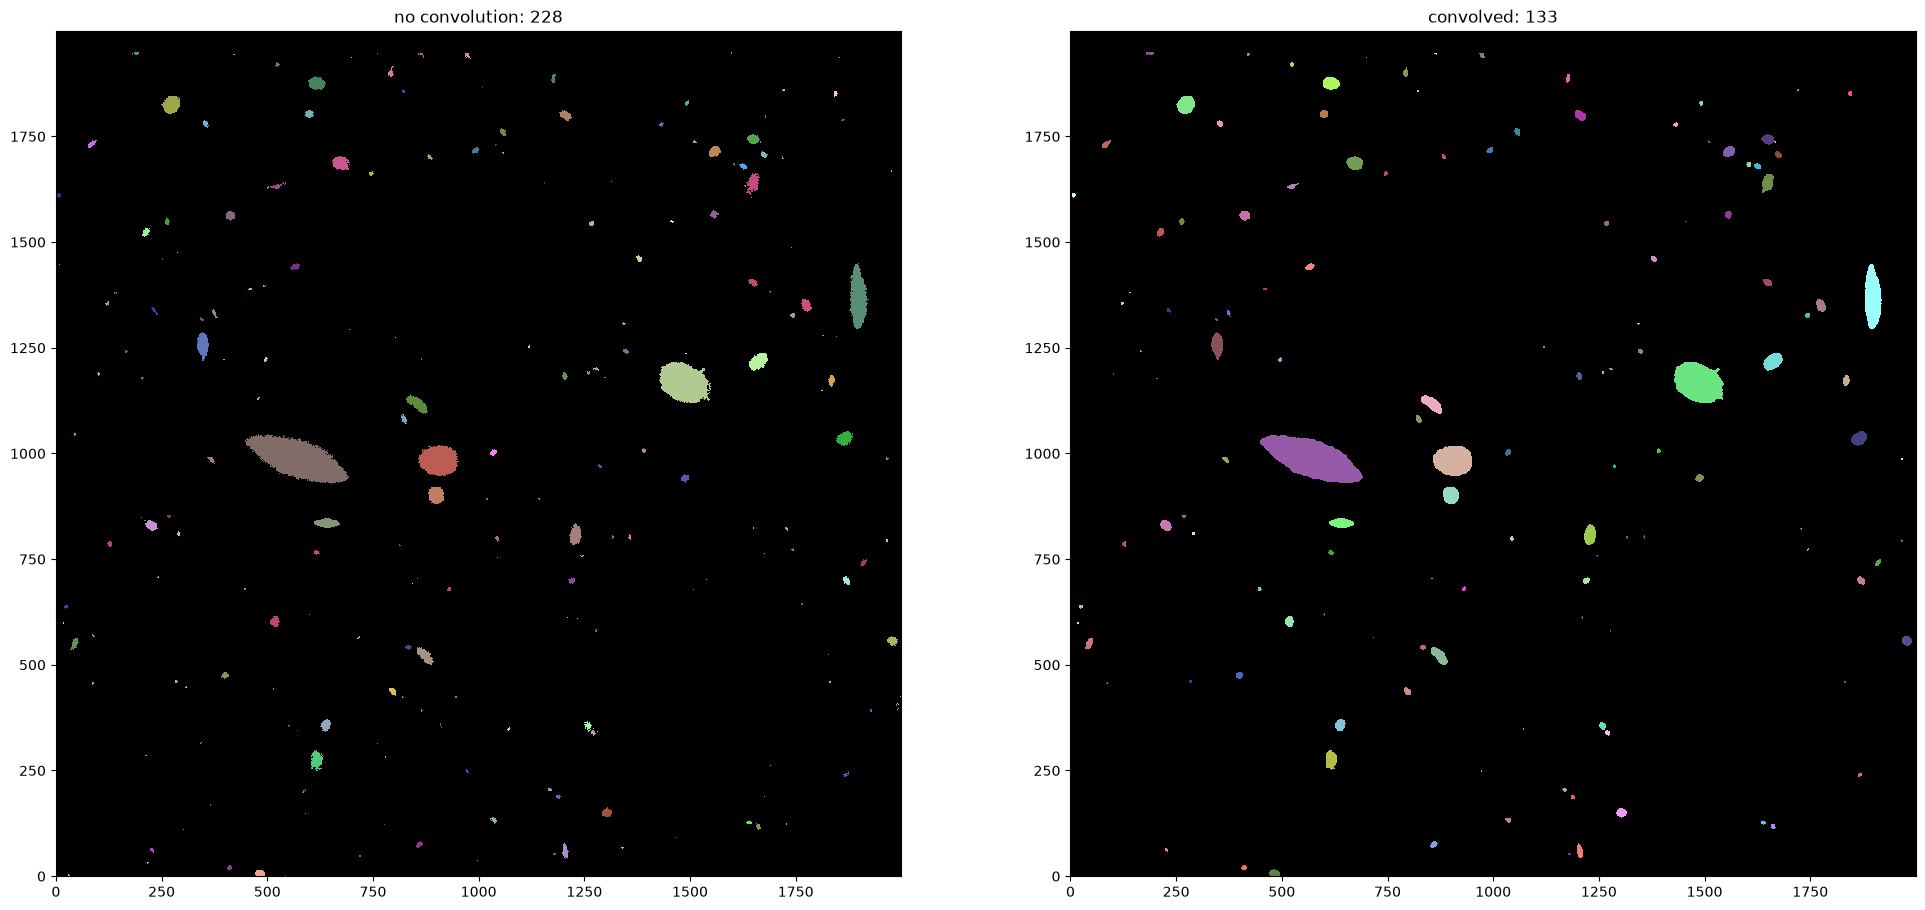

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(segm_local.data, origin="lower", cmap=segm_local.cmap, interpolation="nearest")
ax[0].set_title(f"no convolution: {segm_local.n_labels}")
ax[1].imshow(segm_conv.data, origin="lower", cmap=segm_conv.cmap, interpolation="nearest")
ax[1].set_title(f"convolved: {segm_conv.n_labels}")
plt.show()

In [34]:
# deblending sources to separate the sources that might have covered each other. 

In [35]:
# deblending sources to separate the sources that might have covered each other. 
from photutils.segmentation import deblend_sources
from collections import defaultdict

# Define MIN_NPIX before using it
MIN_NPIX = int(np.ceil(0.5 * psf_area_pix))  # ~half a PSF footprint

segm_deblend = deblend_sources(
    conv,
    segm_conv,
    n_pixels=MIN_NPIX,
    n_levels=32,
    contrast=0.001,
    progress_bar=False,
)
print(f"After deblending: {segm_deblend.n_labels} sources")

# Build parent-child relationships
parent_of = {}
orphans = []
for lab, sl in zip(segm_deblend.labels, segm_deblend.slices):
    child = segm_deblend.data[sl] == lab
    parents = segm_conv.data[sl][child]
    parents = parents[parents > 0]
    if parents.size == 0:
        orphans.append(int(lab))
        parent_of[int(lab)] = int(lab)  # Self-parent if orphan
    else:
        parent_of[int(lab)] = int(np.bincount(parents).argmax())

children_of = defaultdict(list)
for lab, p in parent_of.items():
    children_of[p].append(lab)

# For single sources (not deblended), map to themselves
for lab in segm_conv.labels:
    if lab not in children_of:
        children_of[lab] = [lab]
        parent_of[lab] = lab

shreds = {p: ch for p, ch in children_of.items() if len(ch) > 1}

print(f"{segm_conv.n_labels} parents -> {segm_deblend.n_labels} children")
print(f"{len(shreds)} parents split, producing {sum(len(ch) for ch in shreds.values())} children")

NameError: name 'psf_area_pix' is not defined

In [36]:
# plotting again to observe deblended objects. 

NameError: name 'segm_deblend' is not defined

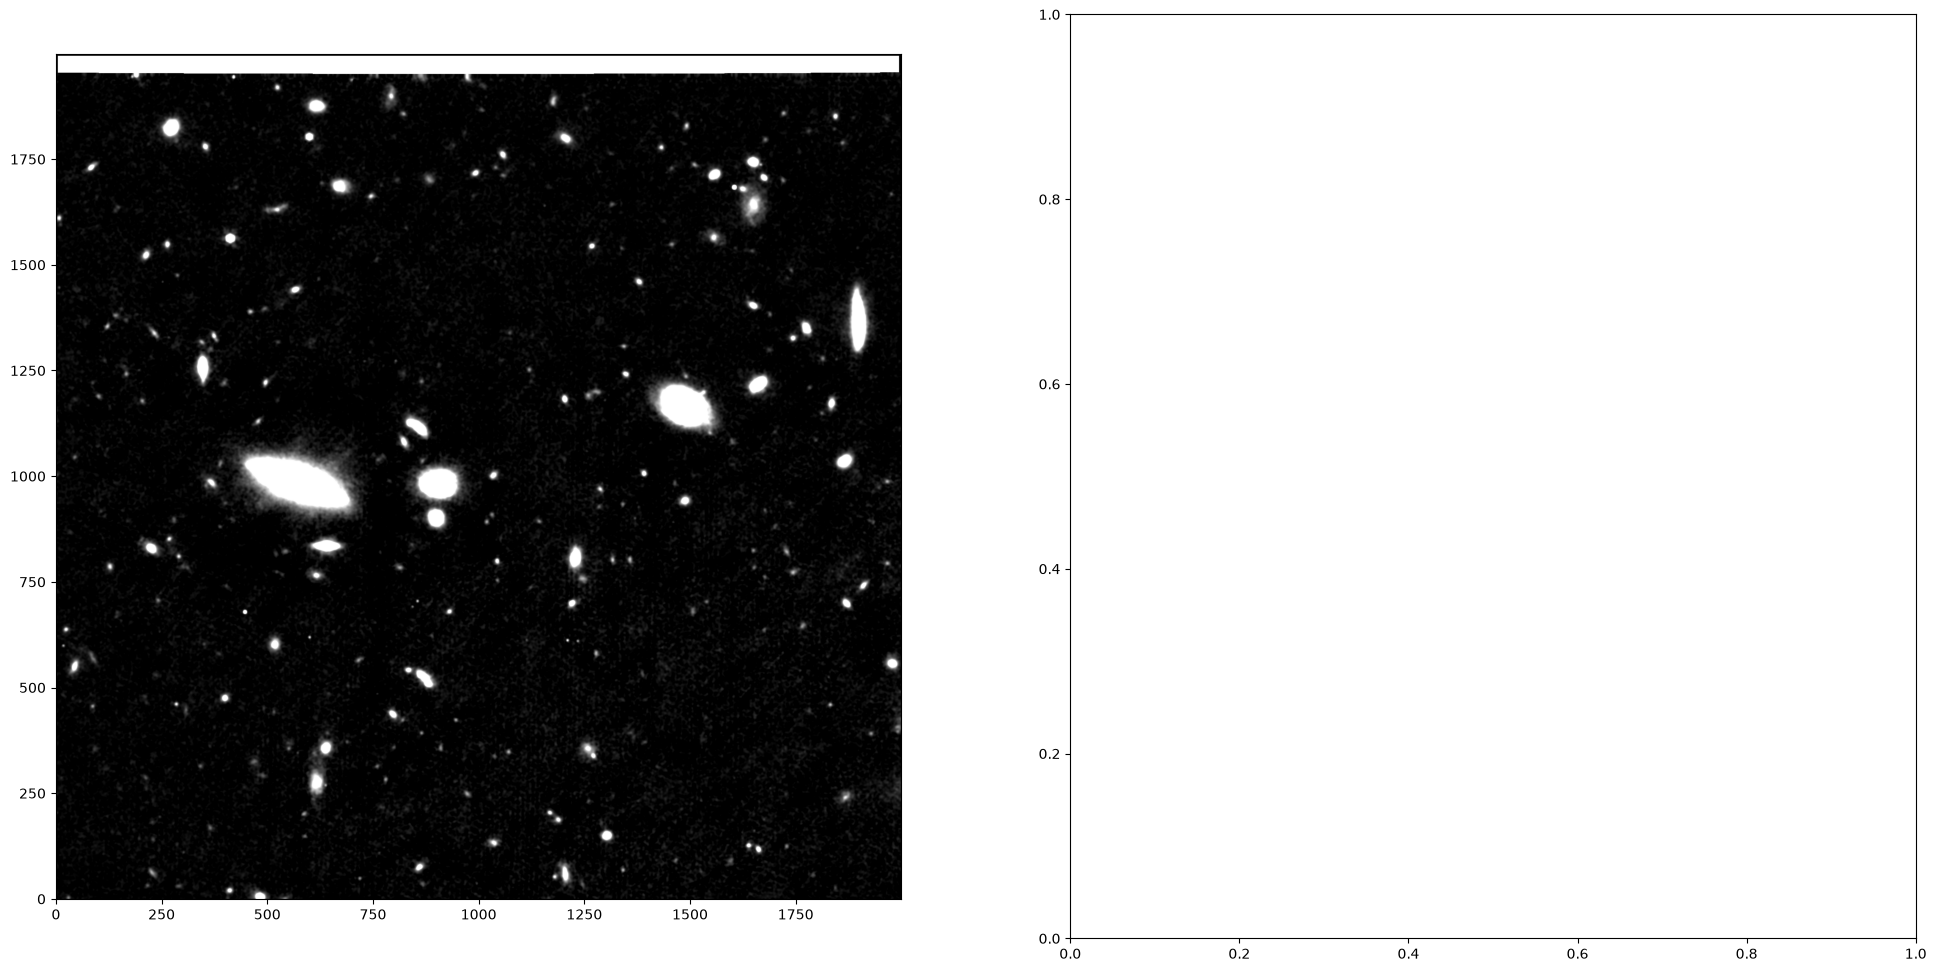

In [37]:
# plotting again to observe deblended objects. 
fig, ax = plt.subplots(1, 2, figsize=(24, 12))
ax[0].imshow(conv, origin="lower", cmap="grey", vmin=0, vmax=10*noise)
ax[1].imshow(segm_deblend.data, origin="lower", cmap=segm_deblend.cmap,
             interpolation="nearest")
plt.show()

In [ ]:
# keeping track of the celestial coordinates of sources in the sky

In [ ]:
# the "WCS" class in the "astropy.wcs" module manages World Coordinate System

In [38]:
from astropy.wcs import WCS
wcs_full = WCS(file["SCI"].header)
wcs_cut  = wcs_full[y0:y1, x0:x1]

Set DATE-AVG to '2022-12-21T13:09:40.140' from MJD-AVG.
Set DATE-END to '2022-12-21T13:36:37.819' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [39]:
# let's do some math ....

In [40]:
from astropy.wcs.utils import proj_plane_pixel_scales
import astropy.units as u

pixscale = (proj_plane_pixel_scales(wcs_cut)[0] * u.deg).to(u.arcsec).value       # almost match with the 0.03"/px number announced by CEERS documentation
psf_fwhm_arcsec = (4.44e-6 / 6.5) * 206265                                        # F444W — verify against JWST docs
psf_fwhm_pix    = psf_fwhm_arcsec / pixscale
psf_sigma_pix   = psf_fwhm_pix / 2.355
psf_area_pix    = np.pi * (psf_fwhm_pix / 2)**2

print(f"{pixscale:.4f} arcsec/pix | FWHM {psf_fwhm_pix:.2f} pix | "
      f"sigma {psf_sigma_pix:.2f} pix | PSF area {psf_area_pix:.1f} pix^2")

0.0300 arcsec/pix | FWHM 4.70 pix | sigma 1.99 pix | PSF area 17.3 pix^2


In [41]:
from collections import defaultdict
 
parent_of = {}
orphans = []
for lab, sl in zip(segm_deblend.labels, segm_deblend.slices):
    child = segm_deblend.data[sl] == lab
    parents = segm_conv.data[sl][child]
    parents = parents[parents > 0]          # drop background pixels
    if parents.size == 0:                   # guard: should never happen
        orphans.append(int(lab))
        parent_of[int(lab)] = 0
    else:
        parent_of[int(lab)] = int(np.bincount(parents).argmax())
 
children_of = defaultdict(list)
for lab, p in parent_of.items():
    children_of[p].append(lab)
 
shreds = {p: ch for p, ch in children_of.items() if len(ch) > 1}
 
print(f"{segm_conv.n_labels} parents -> {segm_deblend.n_labels} children")
print(f"{len(shreds)} parents split, producing "
      f"{sum(len(ch) for ch in shreds.values())} children")
if shreds:
    print("shredded parents (parent: children):")
    for p, ch in sorted(shreds.items()):
        print(f"   {p:4d}: {ch}")
 
# SANITY CHECK -- must print nothing. A child mapped to background means the
# map is untrustworthy and everything downstream inherits the error.
assert not orphans, f"children mapped to background: {orphans}"

NameError: name 'segm_deblend' is not defined

In [42]:
def _parent_map(sd, sc):
    """Parent map for an arbitrary deblend run (same logic as In [44])."""
    from collections import defaultdict
    po = {}
    for lab, sl in zip(sd.labels, sd.slices):
        pr = sc.data[sl][sd.data[sl] == lab]
        pr = pr[pr > 0]
        po[int(lab)] = int(np.bincount(pr).argmax()) if pr.size else 0
    co = defaultdict(list)
    for l, p in po.items():
        co[p].append(l)
    return po, co
 
print(f"{'contrast':>9} {'children':>9} {'split':>6}   flux shares of split parents")
for c in [0.001, 0.005, 0.01, 0.05, 0.1]:
    sd = deblend_sources(conv, segm_conv, n_pixels=MIN_NPIX, n_levels=32,
                         contrast=c, progress_bar=False)
    po, co = _parent_map(sd, segm_conv)
    sh = {p: ch for p, ch in co.items() if len(ch) > 1}
    shares = []
    for p, ch in sorted(sh.items()):
        tot = cut_sub[segm_conv.data == p].sum()
        shares.append((p, [round(float(cut_sub[sd.data == l].sum() / tot), 3)
                           for l in ch]))
    print(f"{c:9.3f} {sd.n_labels:9d} {len(sh):6d}   {shares}")
 

 contrast  children  split   flux shares of split parents


NameError: name 'MIN_NPIX' is not defined

In [43]:
# cataloging

In [44]:
err_cut = err[y0:y1, x0:x1].astype(np.float64)

In [45]:
# Create source catalog on deblended segmentation (for flux measurements)
from photutils.segmentation import SourceCatalog

cat = SourceCatalog(
    data=cut_sub,
    segmentation_image=segm_deblend,
    convolved_data=conv,
    error=err_cut,
    mask=cut_mask,
    wcs=wcs_cut,
)

tbl = cat.to_table(columns=[
    "label", "x_centroid", "y_centroid", "sky_centroid",
    "bbox_xmin", "bbox_xmax", "bbox_ymin", "bbox_ymax",
    "area", "segment_flux", "segment_flux_err",
    "semimajor_axis", "semiminor_axis", "eccentricity", "orientation",
    "max_value",
])
print(f"Catalog created with {len(tbl)} entries (including siblings)")

# Re-measure on original (unconvolved) data, keeping the deblended segmentation
cat_true = SourceCatalog(
    data=cut_sub,
    segmentation_image=segm_deblend,
    error=err_cut,
    mask=cut_mask,
    wcs=wcs_cut,
)

# Extract true morphological measurements
tbl["semimajor_axis"] = cat_true.semimajor_axis
tbl["semiminor_axis"] = cat_true.semiminor_axis
tbl["eccentricity"] = cat_true.eccentricity
tbl["orientation"] = cat_true.orientation
tbl["max_value"] = cat_true.max_value

print(f"Morphologies remeasured on unconvolved data")

NameError: name 'segm_deblend' is not defined

In [46]:
snr = (tbl["segment_flux"] / tbl["segment_flux_err"]).value

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(np.log10(snr), bins=30);                      ax[0].set_xlabel("log10 integrated SNR")
ax[1].hist(np.log10(tbl["area"].value), bins=30);        ax[1].set_xlabel("log10 area [pix^2]")
ax[2].scatter(np.log10(tbl["area"].value), np.log10(snr), s=8)
ax[2].set_xlabel("log10 area"); ax[2].set_ylabel("log10 SNR")
ax[2].axvline(np.log10(np.pi * psf_fwhm_pix**2 / 4), color="r", ls="--")
plt.tight_layout(); plt.show()

NameError: name 'tbl' is not defined

In [47]:
flux = tbl["segment_flux"].value
ferr = tbl["segment_flux_err"].value

snr = np.divide(flux, ferr, out=np.full_like(flux, np.nan), where=(ferr > 0))
tbl["snr"] = snr

print("zero flux:", (flux == 0).sum(), "| negative:", (flux < 0).sum(),
      "| bad err:", ((ferr <= 0) | ~np.isfinite(ferr)).sum())

ok = np.isfinite(snr) & (snr > 0) & (tbl["area"].value > 0)
print(f"{ok.sum()} of {len(tbl)} plottable")

for name, arr in [("snr", snr[ok]),
                  ("area", tbl["area"].value[ok]),
                  ("semiminor", tbl["semiminor_axis"].value[ok])]:
    print(f"{name:10s}", np.percentile(arr, [5, 25, 50, 75, 95]).round(2))

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].hist(np.log10(snr[ok]), bins=30); ax[0].set_xlabel("log10 SNR")
ax[1].hist(np.log10(tbl["area"].value[ok]), bins=30); ax[1].set_xlabel("log10 area")
ax[2].scatter(np.log10(tbl["area"].value[ok]), np.log10(snr[ok]), s=8)
ax[2].axvline(np.log10(psf_area_pix), color="r", ls="--")
ax[2].set_xlabel("log10 area"); ax[2].set_ylabel("log10 SNR")
plt.tight_layout(); plt.show()

NameError: name 'tbl' is not defined

In [48]:
from scipy.ndimage import binary_dilation
 
def blend_metrics(segm, pad=3):
    d = segm.data
    bf, cf = {}, {}
    for lab in segm.labels:
        sl = segm.slices[segm.get_index(lab)]
        y0 = max(sl[0].start - pad, 0); y1 = min(sl[0].stop + pad, d.shape[0])
        x0 = max(sl[1].start - pad, 0); x1 = min(sl[1].stop + pad, d.shape[1])
        sub = d[y0:y1, x0:x1]
        own = sub == lab
        other = (sub != 0) & ~own
        boundary = binary_dilation(own) & ~own
        bf[int(lab)] = other.sum() / max(own.sum(), 1)
        cf[int(lab)] = (boundary & other).sum() / max(boundary.sum(), 1)
    return bf, cf
 
_bf, _cf = blend_metrics(segm_deblend)
tbl["blend_frac"]   = [_bf[int(l)] for l in tbl["label"]]
tbl["contact_frac"] = [_cf[int(l)] for l in tbl["label"]]
tbl["warn_blended"] = np.asarray(tbl["contact_frac"]) > 0.10
 
print(f"warn_blended: {np.asarray(tbl['warn_blended']).sum()} of {len(tbl)} "
      f"(NOT a rejection)")
print("contact_frac percentiles:",
      np.percentile(np.asarray(tbl["contact_frac"]), [50, 75, 90, 95, 99]).round(3))
 

NameError: name 'segm_deblend' is not defined

In [49]:
# quality validation filter to drop the trash sources

In [50]:
# filters (logic to drop a source): 

# 1. negative flux sources (flag_badflux)
# 2. semi-minor axis of the ellipse < MIN_SEMIMINOR || ellipse eccentricity > maximum eccentricity (np.mean(ecc) + std(ecc)) (flag_unresolved)
# 3. area < ~ 17.3 pix^2 (psf_area_pix) (flag_small)
# 4. small signal to noise ratio (SNR) < MIN_SNR (flag_lowsnr)
# 5. source too close to image edge (bbox within EDGE_BUFFER pixels of border) (flag_edge)
# 6. too many bad pixels in source footprint (badfrac > MAX_BADFRAC = 0.05) (flag_baddata)
# 7. mismatch between area and SNR normalized values (|area_norm - snr_norm| > 3.0) (flag_snr_area_mismatch)

In [51]:
# Calculate deblending information BEFORE any filtering
tbl["parent_label"] = [parent_of[int(l)] for l in tbl["label"]]
tbl["n_siblings"] = [len(children_of[parent_of[int(l)]]) - 1
                     for l in tbl["label"]]
tbl["is_deblended_child"] = np.asarray(tbl["n_siblings"]) > 0
tbl["warn_shredded"] = np.asarray(tbl["is_deblended_child"])

print(f"Deblended children: {np.asarray(tbl['is_deblended_child']).sum()} of {len(tbl)}")
print(f"These are NOT rejections -- they are real galaxy substructures")

MIN_SEMIMINOR = 0.8 * psf_sigma_pix
MIN_AREA      = 0.5 * psf_area_pix  # Relaxed from full PSF area
MIN_SNR       = 10.0
EDGE_BUFFER   = 10
MAX_BADFRAC   = 0.05
ecc = tbl["eccentricity"].value

μ = np.mean(ecc)
σ = np.std(ecc)
k = 1
ecc_min = μ - k * σ
ecc_max = μ + k * σ

area_vals = tbl["area"].value
area_normalized = (area_vals - np.median(area_vals)) / np.std(area_vals)
snr_normalized = (snr - np.median(snr)) / np.std(snr)
snr_area_mismatch = np.abs(area_normalized - snr_normalized) > 3.0

ny, nx = cut_sub.shape
tbl["badfrac"] = np.array([
    cut_mask[sl][segm_deblend.data[sl] == lab].mean()
    for lab, sl in zip(segm_deblend.labels, segm_deblend.slices)])

tbl["flag_badflux"]    = ~np.isfinite(snr) | (flux <= 0)
tbl["flag_unresolved"] = (tbl["semiminor_axis"].value < MIN_SEMIMINOR) | (ecc > ecc_max)
tbl["flag_small"]      = tbl["area"].value < MIN_AREA
tbl["flag_lowsnr"]     = np.nan_to_num(snr, nan=-1) < MIN_SNR
tbl["flag_edge"] = ((tbl["bbox_xmin"] < EDGE_BUFFER) |
                    (tbl["bbox_ymin"] < EDGE_BUFFER) |
                    (tbl["bbox_xmax"] > nx - EDGE_BUFFER) |
                    (tbl["bbox_ymax"] > ny - EDGE_BUFFER))
tbl["flag_baddata"] = tbl["badfrac"] > MAX_BADFRAC
tbl["doubted"] = tbl["eccentricity"].value < ecc_min
tbl["flag_snr_area_mismatch"] = snr_area_mismatch

flagcols = ["flag_badflux", "flag_unresolved", "flag_small",
            "flag_lowsnr", "flag_edge", "flag_baddata", "flag_snr_area_mismatch"]

cols = ["flag_badflux", "flag_unresolved", "flag_small",
            "flag_lowsnr", "flag_edge", "flag_baddata", "doubted", "flag_snr_area_mismatch"]

tbl["keep"] = ~np.any(np.stack([np.asarray(tbl[c]) for c in flagcols]), axis=0)

for c in cols:
    print(f"{c:27s} {np.asarray(tbl[c]).sum():4d}")
print(f"{'KEEP':27s} {np.asarray(tbl['keep']).sum():4d} of {len(tbl)}")

NameError: name 'tbl' is not defined

In [52]:
# Check how many siblings survive filtering
keep = np.asarray(tbl["keep"])
shred = np.asarray(tbl["is_deblended_child"])
print(f"{(keep & shred).sum()} of {shred.sum()} deblended children survive filtering")
print(f"\nSurviving deblended sources (parent: surviving children):")
for p in sorted(shreds.keys()):
    children = shreds[p]
    kept_children = [l for l in children if keep[list(tbl["label"]).index(l)]]
    if kept_children:
        print(f"  Parent {p}: children {children} -> kept {kept_children}")
    else:
        print(f"  Parent {p}: children {children} -> NONE kept (all filtered out)")

NameError: name 'tbl' is not defined

In [53]:
μ, σ 

NameError: name 'μ' is not defined

In [54]:
# configuring cutout settings and cutting them out

In [55]:
from astropy.nddata.utils import Cutout2D

PAD, MIN_SIZE = 2.0, 32

def make_cutouts(row, pad=PAD):
    lab = int(row["label"])
    p   = parent_of[lab]
    
    # Parent bbox for cutout size (keep for context)
    sl  = segm_conv.slices[segm_conv.get_index(p)]
    bh  = sl[0].stop - sl[0].start
    bw  = sl[1].stop - sl[1].start
    pos = ((sl[1].start + sl[1].stop - 1) / 2.0,
           (sl[0].start + sl[0].stop - 1) / 2.0)
    side = int(max(MIN_SIZE, np.ceil(pad * max(bw, bh))))
    kw   = dict(position=pos, size=(side, side), mode="partial")
    
    c_sci = Cutout2D(cut_sub, wcs=wcs_cut, fill_value=np.nan, **kw)
    c_err = Cutout2D(err_cut, fill_value=np.nan, **kw)
    c_seg = Cutout2D(segm_deblend.data, fill_value=0, **kw)
    c_seg_parent = Cutout2D(segm_conv.data, fill_value=0, **kw)
    
    # Create masks
    own  = c_seg.data == lab
    parent_mask = c_seg_parent.data == p
    sibs = [l for l in children_of[p] if l != lab]
    mask_sibling  = np.isin(c_seg.data, sibs)
    mask_neighbor = (c_seg.data != 0) & ~own & ~mask_sibling
    
    return dict(label=lab, parent=p,
                sci=c_sci.data, err=c_err.data, seg=c_seg.data,
                mask_own=own,
                mask_parent=parent_mask,
                mask_sibling=mask_sibling,
                mask_neighbor=mask_neighbor,
                wcs=c_sci.wcs, row=row)

tbl_keep = tbl[np.asarray(tbl["keep"])]
cutouts  = {int(r["label"]): make_cutouts(r) for r in tbl_keep}
print(len(cutouts), "cutouts built")

# SANITY CHECK -- the masks must exactly partition the segmap.
for lab, c in cutouts.items():
    assert not (c["mask_own"] & c["mask_sibling"]).any()
    assert not (c["mask_own"] & c["mask_neighbor"]).any()
    assert not (c["mask_sibling"] & c["mask_neighbor"]).any()
    union = c["mask_own"] | c["mask_sibling"] | c["mask_neighbor"]
    assert np.array_equal(union, c["seg"] != 0)
    # Check parent mask contains own mask
    assert np.all(c["mask_parent"] >= c["mask_own"])
print("mask partition verified")

NameError: name 'tbl' is not defined

In [56]:
# plotting a few filter-passed cutouts. 

In [57]:
# "lime" outlined area: main source 
# "cyan" outlined area: shreded galaxy (siblings of the main part of the galaxy, all together knwon as a single galaxy)
# "magenta" outlinded area: isn't the source, it's known as "others" 

In [58]:
from astropy.visualization import ZScaleInterval
z = ZScaleInterval()

order = np.argsort(-tbl_keep["area"].value)
seen, picks = set(), []
for i in order:
    lab = int(tbl_keep["label"][i - 1])
    p = parent_of[lab]
    if p in seen:
        continue
    seen.add(p)
    picks.append(lab)
    if len(picks) == 5:
        break

fig, axes = plt.subplots(1, 5, figsize=(16, 13))
for a, lab in zip(axes.ravel(), picks):
    c = cutouts[lab]
    lo, hi = z.get_limits(np.nan_to_num(c["sci"]))
    a.imshow(c["sci"], origin="lower", cmap="grey", vmin=lo, vmax=hi)
    a.contour(c["mask_own"],      levels=[0.5], colors="lime",    linewidths=2)
    a.contour(c["mask_parent"],   levels=[0.5], colors="yellow",  linewidths=1, linestyles="--")
    a.contour(c["mask_sibling"],  levels=[0.5], colors="cyan",    linewidths=1)
    a.contour(c["mask_neighbor"], levels=[0.5], colors="magenta", linewidths=1)
    ns = int(c["row"]["n_siblings"])
    a.set_title(f"{lab}  A={c['row']['area'].value:.0f}  "
                f"SNR={c['row']['snr']:.0f}  sib={ns}", fontsize=9)
    a.axis("off")
for a in axes.ravel()[len(picks):]:
    a.axis("off")
plt.tight_layout(); plt.show()

print("lime = this source | yellow dashed = parent | cyan = SIBLING (same galaxy, shredded) | "
      "magenta = NEIGHBOUR (different object)")

NameError: name 'tbl_keep' is not defined

In [59]:
# detecting galaxies from the cutout sources

In [60]:
# 1. stars are point sources well described by PSF

In [61]:
from astropy.modeling.fitting import LevMarLSQFitter
from astropy.modeling.models import Gaussian2D

fitter = LevMarLSQFitter()  # Levenberg-Marquardt least squares fitter

In [62]:
# ============================================
# PROPER SIBLING HANDLING FOR CLASSIFICATION
# ============================================

from astropy.modeling.fitting import LevMarLSQFitter
from astropy.modeling.models import Gaussian2D
from photutils.segmentation import SegmentationImage

# Create a "physical source" segmentation where siblings share the same label
segm_physical_data = np.array(segm_deblend.data)

# Map all children to their parent labels
for lab in segm_deblend.labels:
    p = parent_of[int(lab)]
    if p != lab:  # Only merge if it's a child
        segm_physical_data[segm_physical_data == lab] = p

segm_physical = SegmentationImage(segm_physical_data)
print(f"Physical sources (siblings merged): {segm_physical.n_labels}")
print(f"Original deblended sources: {segm_deblend.n_labels}")

# ============================================
# CLASSIFY PHYSICAL SOURCES (using kept sources only)
# ============================================

fitter = LevMarLSQFitter()
sigma_psf = psf_fwhm_pix / 2.355

# Get list of kept physical labels
kept_physical_labels = set()
for lab in tbl_keep["label"]:
    kept_physical_labels.add(parent_of[int(lab)])

physical_results = []

for label in kept_physical_labels:
    # Get all siblings that belong to this physical source
    siblings = children_of.get(int(label), [int(label)])
    
    # Get bounding box from the ORIGINAL deblended segmentation
    # Find the bounding box that contains all siblings
    sibling_slices = []
    for sib in siblings:
        if sib in segm_deblend.labels:
            sl = segm_deblend.slices[segm_deblend.get_index(sib)]
            sibling_slices.append(sl)
    
    if not sibling_slices:
        continue
    
    # Combine bounding boxes
    y_min = min(sl[0].start for sl in sibling_slices)
    y_max = max(sl[0].stop for sl in sibling_slices)
    x_min = min(sl[1].start for sl in sibling_slices)
    x_max = max(sl[1].stop for sl in sibling_slices)
    
    # Add padding
    pad = 5
    y_min = max(0, y_min - pad)
    y_max = min(cut_sub.shape[0], y_max + pad)
    x_min = max(0, x_min - pad)
    x_max = min(cut_sub.shape[1], x_max + pad)
    
    y_slice = slice(y_min, y_max)
    x_slice = slice(x_min, x_max)
    
    # Extract data
    source_data = cut_sub[y_slice, x_slice].copy()
    source_err_data = err_cut[y_slice, x_slice].copy()
    
    # Create mask for the physical source (includes all siblings)
    physical_mask = np.zeros_like(source_data, dtype=bool)
    for sib in siblings:
        physical_mask |= (segm_deblend.data[y_slice, x_slice] == sib)
    
    # Mask out other sources
    other_sources = (segm_deblend.data[y_slice, x_slice] != 0) & ~physical_mask
    source_data[other_sources] = np.nan
    
    # Get shape
    ny, nx = source_data.shape
    y, x = np.mgrid[:ny, :nx]
    
    # Initial guesses
    initial_amplitude = np.nanmax(source_data)
    
    if not np.isfinite(initial_amplitude) or initial_amplitude <= 0:
        continue
    
    y_indices, x_indices = np.where(physical_mask)
    if len(x_indices) == 0:
        continue
    
    initial_x = np.mean(x_indices)
    initial_y = np.mean(y_indices)
    
    # Build PSF model
    psf_model = Gaussian2D(
        amplitude=initial_amplitude,
        x_mean=initial_x,
        y_mean=initial_y,
        x_stddev=sigma_psf,
        y_stddev=sigma_psf,
        theta=0.0
    )
    
    psf_model.x_stddev.fixed = True
    psf_model.y_stddev.fixed = True
    
    try:
        fitted_model = fitter(psf_model, x, y, source_data, 
                             filter_non_finite=True)
        
        model_values = fitted_model(x, y)
        residuals = source_data - model_values
        
        error_map = source_err_data.copy()
        error_map[other_sources] = np.nan
        error_map[error_map == 0] = np.nan
        
        weighted_residuals = residuals / error_map
        chi2 = np.nansum(weighted_residuals**2)
        
        n_pixels = np.sum(~np.isnan(source_data))
        n_params = 3
        dof = n_pixels - n_params
        
        if dof <= 0:
            continue
        
        chi2_reduced = chi2 / dof
        
        if np.isfinite(chi2_reduced):
            physical_results.append({
                'label': int(label),
                'siblings': siblings,
                'n_siblings': len(siblings),
                'chi2_reduced': chi2_reduced,
                'is_star': chi2_reduced < 3.0,
                'is_galaxy': chi2_reduced >= 3.0
            })
            
    except Exception as e:
        print(f"Physical source {label}: FAILED ({e})")
        continue

# Create classification map
classification = {}
for result in physical_results:
    # Apply the same classification to ALL siblings
    for sibling in result['siblings']:
        classification[sibling] = {
            'physical_label': result['label'],
            'is_star': result['is_star'],
            'is_galaxy': result['is_galaxy'],
            'n_siblings': result['n_siblings'],
            'chi2_reduced': result['chi2_reduced']
        }

# Add classification to the kept table
tbl_keep['is_star'] = [classification.get(int(l), {}).get('is_star', False) 
                        for l in tbl_keep['label']]
tbl_keep['is_galaxy'] = [classification.get(int(l), {}).get('is_galaxy', False) 
                          for l in tbl_keep['label']]
tbl_keep['physical_label'] = [classification.get(int(l), {}).get('physical_label', int(l)) 
                               for l in tbl_keep['label']]

print(f"\nPhysical source classification:")
print(f"  Total physical sources: {len(physical_results)}")
print(f"  Stars: {sum(1 for r in physical_results if r['is_star'])}")
print(f"  Galaxies: {sum(1 for r in physical_results if r['is_galaxy'])}")
print(f"  Deblended (multi-sibling): {sum(1 for r in physical_results if r['n_siblings'] > 1)}")

# Check sibling consistency
print("\nSibling classification consistency check:")
for result in physical_results:
    if result['n_siblings'] > 1:
        print(f"  Physical source {result['label']}: siblings {result['siblings']} "
              f"-> {'STAR' if result['is_star'] else 'GALAXY'} "
              f"(chi2={result['chi2_reduced']:.2f})")

NameError: name 'segm_deblend' is not defined

In [ ]:
# Create final catalog with siblings merged back to parents
from photutils.segmentation import SegmentationImage

# Create merged segmentation for final catalog
segm_final_data = np.array(segm_deblend.data)

# Merge all kept siblings back to their parents
kept_labels = set(tbl_keep["label"].astype(int))
for lab in kept_labels:
    p = parent_of[lab]
    if p != lab and p in kept_labels:
        # Merge child into parent
        segm_final_data[segm_final_data == lab] = p

segm_final = SegmentationImage(segm_final_data)

# Create final source catalog on merged segmentation
cat_final = SourceCatalog(
    data=cut_sub,
    segmentation_image=segm_final,
    error=err_cut,
    mask=cut_mask,
    wcs=wcs_cut,
)

tbl_final = cat_final.to_table(columns=[
    "label", "x_centroid", "y_centroid", "sky_centroid",
    "bbox_xmin", "bbox_xmax", "bbox_ymin", "bbox_ymax",
    "area", "segment_flux", "segment_flux_err",
    "semimajor_axis", "semiminor_axis", "eccentricity", "orientation",
    "max_value",
])

# Add information about original deblending
tbl_final["n_deblended_children"] = [
    len(children_of.get(int(label), [int(label)])) 
    for label in tbl_final["label"]
]
tbl_final["was_deblended"] = tbl_final["n_deblended_children"] > 1

# Calculate SNR for final catalog
flux_final = tbl_final["segment_flux"].value
ferr_final = tbl_final["segment_flux_err"].value
snr_final = np.divide(flux_final, ferr_final, 
                      out=np.full_like(flux_final, np.nan), 
                      where=(ferr_final > 0))
tbl_final["snr"] = snr_final

# Add classification from physical source analysis
physical_classification = {}
for result in physical_results:
    physical_classification[result['label']] = {
        'is_star': result['is_star'],
        'is_galaxy': result['is_galaxy'],
        'chi2_reduced': result['chi2_reduced'],
        'n_siblings': result['n_siblings']
    }

# Add to final table
tbl_final['is_star'] = [
    physical_classification.get(int(label), {}).get('is_star', False)
    for label in tbl_final['label']
]
tbl_final['is_galaxy'] = [
    physical_classification.get(int(label), {}).get('is_galaxy', False)
    for label in tbl_final['label']
]
tbl_final['chi2_reduced'] = [
    physical_classification.get(int(label), {}).get('chi2_reduced', np.nan)
    for label in tbl_final['label']
]

print(f"\nFinal catalog: {len(tbl_final)} physical sources (siblings merged)")
print(f"  Deblended sources: {np.sum(tbl_final['was_deblended'])}")
print(f"  Single sources: {len(tbl_final) - np.sum(tbl_final['was_deblended'])}")
print(f"  Stars identified: {np.sum(tbl_final['is_star'])}")
print(f"  Galaxies: {np.sum(tbl_final['is_galaxy'])}")

# Save final catalog (with all sources)
tbl_final.write("catalog_final_merged.ecsv", overwrite=True)
print("Saved: catalog_final_merged.ecsv (all sources with siblings merged)")

# Create galaxy-only catalog
tbl_galaxies = tbl_final[tbl_final["is_galaxy"]]
tbl_galaxies.write("catalog_galaxies_final.ecsv", overwrite=True)
print(f"Saved: catalog_galaxies_final.ecsv ({len(tbl_galaxies)} galaxies)")

In [ ]:
# dropping stars from the sources

In [ ]:
# dropping stars from the sources
print("Final merged sources classified as GALAXIES:")
galaxy_mask = tbl_final["is_galaxy"]
for row in tbl_final[galaxy_mask]:
    label = int(row["label"])
    chi2_val = row["chi2_reduced"]
    was_deblended = bool(row["was_deblended"])
    n_children = int(row["n_deblended_children"])
    
    print(f"Label {label}: chi2={chi2_val:.2f} | deblended={was_deblended} (n_children={n_children})")

In [ ]:
# 2. galaxies are extended sources requiring Seric profiles 

In [ ]:
# 3. classification

In [ ]:
# all these sources are now eliminated from the list:
# tiny bright point (less than minimum area), stars, cosmic rays

In [ ]:
# extracting galaxies to the folder named "cutouts", each in .fits format

In [ ]:
# ============================================
# PROPER CUTOUT EXPORT WITH SIBLING AWARENESS
# ============================================

def write_physical_source_cutout(physical_label, siblings, classification_info):
    """Write a single FITS file for a physical source containing all siblings."""
    
    # Find bounding box containing ALL siblings
    sibling_slices = []
    for sib in siblings:
        if sib in segm_deblend.labels:
            sl = segm_deblend.slices[segm_deblend.get_index(sib)]
            sibling_slices.append(sl)
    
    if not sibling_slices:
        return None
    
    # Combine bounding boxes with padding
    pad = 10
    y_min = max(0, min(sl[0].start for sl in sibling_slices) - pad)
    y_max = min(cut_sub.shape[0], max(sl[0].stop for sl in sibling_slices) + pad)
    x_min = max(0, min(sl[1].start for sl in sibling_slices) - pad)
    x_max = min(cut_sub.shape[1], max(sl[1].stop for sl in sibling_slices) + pad)
    
    y_slice = slice(y_min, y_max)
    x_slice = slice(x_min, x_max)
    
    # Extract data
    sci_data = cut_sub[y_slice, x_slice].copy()
    err_data = err_cut[y_slice, x_slice].copy()
    
    # Create segmentation maps
    seg_physical = segm_physical.data[y_slice, x_slice].copy()
    seg_deblend = segm_deblend.data[y_slice, x_slice].copy()
    
    # Create masks for each sibling
    sibling_masks = {}
    for i, sib in enumerate(siblings, 1):
        mask = (seg_deblend == sib).astype(np.uint8)
        sibling_masks[f'SIB{i:02d}'] = mask
    
    # Create combined mask
    combined_mask = np.zeros_like(sci_data, dtype=np.uint8)
    for sib in siblings:
        combined_mask |= (seg_deblend == sib).astype(np.uint8)
    
    # Create other sources mask
    other_mask = ((seg_deblend != 0) & (combined_mask == 0)).astype(np.uint8)
    
    # Get WCS for this cutout
    wcs_cutout = wcs_cut[y_slice, x_slice]
    
    # Calculate centroid (weighted by flux)
    y_indices, x_indices = np.where(combined_mask > 0)
    if len(y_indices) > 0 and len(x_indices) > 0:
        flux_weights = sci_data[y_indices, x_indices]
        total_flux = np.nansum(flux_weights)
        if total_flux > 0 and np.isfinite(total_flux):
            y_centroid = np.nansum(y_indices * flux_weights) / total_flux
            x_centroid = np.nansum(x_indices * flux_weights) / total_flux
            sky_coord = wcs_cutout.pixel_to_world(x_centroid, y_centroid)
        else:
            sky_coord = None
    else:
        sky_coord = None
    
    # Create FITS file
    hdr = wcs_cutout.to_header()
    primary = fits.PrimaryHDU(header=hdr)
    primary.header['PHYSLAB'] = physical_label
    primary.header['NSIBS'] = len(siblings)
    primary.header['ISSTAR'] = classification_info['is_star']
    primary.header['ISGAL'] = classification_info['is_galaxy']
    primary.header['CHI2RED'] = classification_info['chi2_reduced']
    primary.header['FILTER'] = 'F444W'
    primary.header['SURVEY'] = 'CEERS'
    
    if sky_coord:
        primary.header['RA'] = sky_coord.ra.deg
        primary.header['DEC'] = sky_coord.dec.deg
    
    hdus = [primary,
            fits.ImageHDU(sci_data.astype(np.float32), name='SCI'),
            fits.ImageHDU(err_data.astype(np.float32), name='ERR'),
            fits.ImageHDU(seg_physical.astype(np.int32), name='SEGPHYS'),
            fits.ImageHDU(seg_deblend.astype(np.int32), name='SEGDEBL'),
            fits.ImageHDU(combined_mask, name='MASKCOMB'),
            fits.ImageHDU(other_mask, name='MASKOTHER')]
    
    # Add individual sibling masks
    for name, mask in sibling_masks.items():
        hdus.append(fits.ImageHDU(mask, name=name))
    
    # Save file
    filename = f"cutouts_physical/phys_src_{physical_label:05d}.fits"
    fits.HDUList(hdus).writeto(filename, overwrite=True)
    
    return filename

# Create output directory
import os
os.makedirs("cutouts_physical", exist_ok=True)

# Export all physical sources (galaxies only)
exported_files = []
exported_galaxies = 0
exported_stars = 0

for result in physical_results:
    if result['is_galaxy']:  # Export only galaxies
        filename = write_physical_source_cutout(
            result['label'], 
            result['siblings'],
            result
        )
        if filename:
            exported_files.append(filename)
            exported_galaxies += 1
            print(f"Exported galaxy: {filename} (siblings: {result['siblings']})")
    else:
        exported_stars += 1

print(f"\nExport complete:")
print(f"  Total galaxies exported: {exported_galaxies}")
print(f"  Stars skipped: {exported_stars}")
print(f"  Files in cutouts_physical/: {len(exported_files)}")

# Also save the final tables
tbl_galaxies = tbl_keep[tbl_keep["is_galaxy"]]
tbl_galaxies.write("catalog_galaxies_final.ecsv", overwrite=True)
print(f"\nSaved catalogs:")
print(f"  - catalog_galaxies_final.ecsv ({len(tbl_galaxies)} galaxies)")

In [ ]:
#   pdf report: 
# . mosaic full picture (with the name of the given file)
# . date and position the full mosaic captured
# . filter and detector information
# . masking the detected galaxies with their label (categorized by their color: doubted VS. gauranteed ones)
# . each galaxy displayed and reported on a separate card with corresponding data (declanation angle, position coordinates, label etc.)
# . creadits